# Imports

In [ ]:
# pip install tensorflow

In [2]:
import tensorflow as tf

2022-01-07 06:39:28.803989: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-01-07 06:39:28.804046: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
import os

# Parameters

In [5]:
IMG_SIZE = 128

In [6]:
NUM_KEYPOINTS = 2*8

In [7]:
MODELS_DIR = '/home/usman/truetoform/models'

In [8]:
MODEL_NAME = 'ResNet50ABackbone'

# Creating Model

In [9]:
backbone = tf.keras.applications.ResNet50(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights=None)

2022-01-07 06:39:41.151611: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-01-07 06:39:41.151659: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2022-01-07 06:39:41.151682: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (truetoform-vm): /proc/driver/nvidia/version does not exist
2022-01-07 06:39:41.151985: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
backbone.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']      

In [11]:
inputs = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3))

In [12]:
x = tf.keras.applications.resnet50.preprocess_input(inputs)

In [13]:
x = backbone(x)

In [14]:
# x = tf.keras.layers.Conv2D(1024, kernel_size=1, strides=1, activation='relu')(x)

In [15]:
# x = tf.keras.layers.Conv2D(512, kernel_size=1, strides=1, activation='relu')(x)

In [16]:
# x = tf.keras.layers.Conv2D(256, kernel_size=1, strides=1, activation='relu')(x)

In [17]:
x = tf.keras.layers.Conv2D(
        NUM_KEYPOINTS, kernel_size=4, strides=1, activation="relu"
    )(x)

In [18]:
# x = tf.keras.layers.Conv2D(
#         NUM_KEYPOINTS, kernel_size=3, strides=1, activation="relu"
#     )(x)

In [19]:
x = tf.keras.layers.Flatten()(x)

In [20]:
outputs = tf.keras.layers.Dense(NUM_KEYPOINTS, activation='sigmoid')(x)

In [21]:
model = tf.keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)

In [22]:
model.summary()

Model: "ResNet50ABackbone"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 128, 128, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 128, 128, 3)      0         
                                                                 
 resnet50 (Functional)       (None, 4, 4, 2048)        23587712  
                                                                 
 conv2d (Conv2D)             (None, 1, 1, 16)          524304    
                                                                 
 flatten (Flatten)           (None, 16)                0         
                                                 

In [82]:
model_path = os.path.join(MODELS_DIR, MODEL_NAME)
model_path

In [83]:
if not os.path.exists(model_path):
    os.makedirs(model_path)

In [84]:
model.save(model_path)

2022-01-06 10:13:20.889493: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: /home/usman/truetoform/models/ResNet50ABackbone/assets


/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/keras/engine/functional.py:1410: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  layer_config = serialize_layer_fn(layer)
/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/keras/saving/saved_model/layer_serialization.py:112: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  return generic_utils.serialize_keras_object(obj)


In [66]:
model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(1e-4))

In [80]:
# train_datagen = ImageDataGenerator(rescale=1 / 255)

In [81]:
# train_generator = train_datagen.flow_from_directory(
#     TRAINING_DIR,
#     batch_size=64,
#     target_size=(224, 224)
# )

In [84]:
def mean_square_error(model, imgs, kps):
    kps_hat = model.predict(imgs)
    mse = tf.keras.losses.mean_squared_error(kps_hat, kps)
    return mse

In [89]:
imgs_list = list(os.walk(TRAINING_DIR))[0][2]

In [90]:
len(imgs_list)

9955

In [101]:
import matplotlib.pyplot as plt

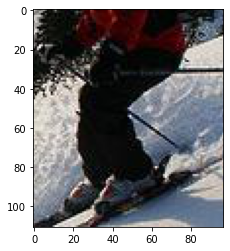

In [109]:
img = plt.imread(os.path.join(TRAINING_DIR, imgs_list[3]))
plt.imshow(img)

In [ ]:
BATCH_SIZE = 32
for start, end in list(zip(list(range(len(imgs_list)))[::BATCH_SIZE], 
                           list(range(BATCH_SIZE, len(imgs_list)))[::BATCH_SIZE] + [len(imgs_list)])):
    batch = imgs_list[start:end]
    with tf.GradientTape() as tape:
        losses = mean_square_error(model, )
        del batch, user_i, items_pos, items_neg
        while first_time:
        loss_at_epoch.append(losses.numpy())
        best_loss = loss_at_epoch[-1]
        first_time = False
        grads = tape.gradient(losses, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        loss_at_iter.append(losses.numpy())